In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
import joblib, json, warnings
warnings.filterwarnings('ignore')

lr   = joblib.load('../models/logreg_woe.pkl')
lgbm = joblib.load('../models/lgbm_model.pkl')

with open('../models/feature_names.json') as f:
    features = json.load(f)

train = pd.read_parquet('../data/processed/train_woe.parquet')
oot   = pd.read_parquet('../data/processed/oot_woe.parquet')

train_scores = pd.read_parquet('../data/processed/train_scores.parquet')
oot_scores   = pd.read_parquet('../data/processed/oot_scores.parquet')

TARGET  = 'TARGET'
X_train = train[features]
y_train = train[TARGET]
X_oot   = oot[features]
y_oot   = oot[TARGET]

print(f"Train: {X_train.shape}")
print(f"Holdout:   {X_oot.shape}")

Train: (246008, 56)
Holdout:   (61503, 56)


In [2]:
def ks_stat(y_true, y_prob):
    """KS statistic — max separation between TPR and FPR."""
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    return round(max(tpr - fpr), 4), thresholds[np.argmax(tpr - fpr)]

def gini(y_true, y_prob):
    return round(2 * roc_auc_score(y_true, y_prob) - 1, 4)


def psi(expected, actual, bins=10):
    """
    群体稳定性指标PSI，用于监测分数/特征分布漂移
    PSI < 0.1  ：无漂移，稳定
    PSI 0.1~0.2：轻微漂移，持续观察
    PSI > 0.2  ：显著漂移，需要排查原因
    """
    # 在基准数据集上分十分位，生成分箱断点
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    # 去除重复断点，避免分箱报错
    breakpoints = np.unique(breakpoints)

    # 统计基准集、实际集每个分箱内样本占比
    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    # 防止占比为0时log计算出现除以0报错，极小值替换0
    expected_pct = np.where(expected_pct == 0, 1e-6, expected_pct)
    actual_pct = np.where(actual_pct == 0, 1e-6, actual_pct)

    # PSI计算公式求和
    psi_value = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return round(psi_value, 4)


def full_eval(name, y_tr, p_tr, y_ot, p_ot):
    """模型完整评估函数，一次性计算训练集 & 随机留出验证集各项指标"""
    ks_tr, _ = ks_stat(y_tr, p_tr)
    ks_ot, _ = ks_stat(y_ot, p_ot)
    return {
        'Model'    : name,
        'AUC Train': round(roc_auc_score(y_tr, p_tr), 4),
        'AUC Holdout'  : round(roc_auc_score(y_ot, p_ot), 4),
        'KS Train' : ks_tr,
        'KS Holdout'   : ks_ot,
        'Gini Train': gini(y_tr, p_tr),
        'Gini Holdout'  : gini(y_ot, p_ot),
    }



In [3]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)

p_dummy_tr = dummy.predict_proba(X_train)[:, 1]
p_dummy_ot = dummy.predict_proba(X_oot)[:, 1]
p_lr_tr    = lr.predict_proba(X_train)[:, 1]
p_lr_ot    = lr.predict_proba(X_oot)[:, 1]
p_lgbm_tr  = lgbm.predict_proba(X_train)[:, 1]
p_lgbm_ot  = lgbm.predict_proba(X_oot)[:, 1]

results = pd.DataFrame([
    full_eval('DummyClassifier',    y_train, p_dummy_tr, y_oot, p_dummy_ot),
    full_eval('Logistic Regression',y_train, p_lr_tr,    y_oot, p_lr_ot),
    full_eval('LightGBM',           y_train, p_lgbm_tr,  y_oot, p_lgbm_ot),
]).set_index('Model')

print(results.to_string())



                     AUC Train  AUC Holdout  KS Train  KS Holdout  Gini Train  Gini Holdout
Model                                                                                      
DummyClassifier         0.5000       0.5016    0.0000      0.0032     -0.0000        0.0032
Logistic Regression     0.7625       0.7621    0.3941      0.3989      0.5249        0.5242
LightGBM                0.8278       0.7723    0.4987      0.4149      0.6557        0.5446


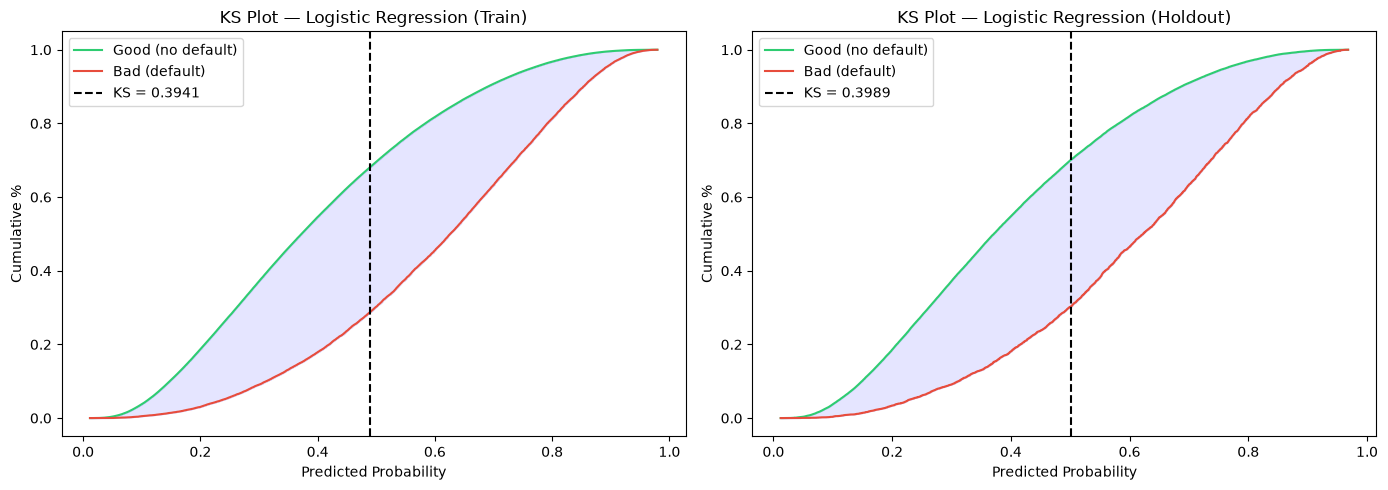

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y, p, label) in zip(axes, [
    (y_train, p_lr_tr, 'Train'),
    (y_oot,   p_lr_ot, 'Holdout'),
]):
    df = pd.DataFrame({'prob': p, 'target': y}).sort_values('prob')
    total_good = (y == 0).sum()
    total_bad  = (y == 1).sum()

    # 累计好人占全部好人比例、累计坏人占全部坏人比例
    cum_good = np.cumsum(df['target'] == 0) / total_good
    cum_bad  = np.cumsum(df['target'] == 1) / total_bad

    ks, _ = ks_stat(y, p)
    ks_idx = np.argmax(np.abs(cum_bad.values - cum_good.values))

    ax.plot(df['prob'].values, cum_good.values, label='Good (no default)', color='#2ecc71')
    ax.plot(df['prob'].values, cum_bad.values,  label='Bad (default)',     color='#e74c3c')
    ax.axvline(df['prob'].values[ks_idx], linestyle='--', color='black',
               label=f'KS = {ks}')
    ax.fill_between(df['prob'].values,
                    cum_good.values, cum_bad.values, alpha=0.1, color='blue')
    ax.set_title(f'KS Plot — Logistic Regression ({label})')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Cumulative %')
    ax.legend()

plt.tight_layout()
plt.show()



PSI (Scorecard scores) : 0.0001
PSI (LR probabilities) : 0.0002
Scorecard PSI: 0.0001 → ✅ Stable – no action needed（稳定，无需处理）
LR Prob PSI: 0.0002 → ✅ Stable – no action needed（稳定，无需处理）


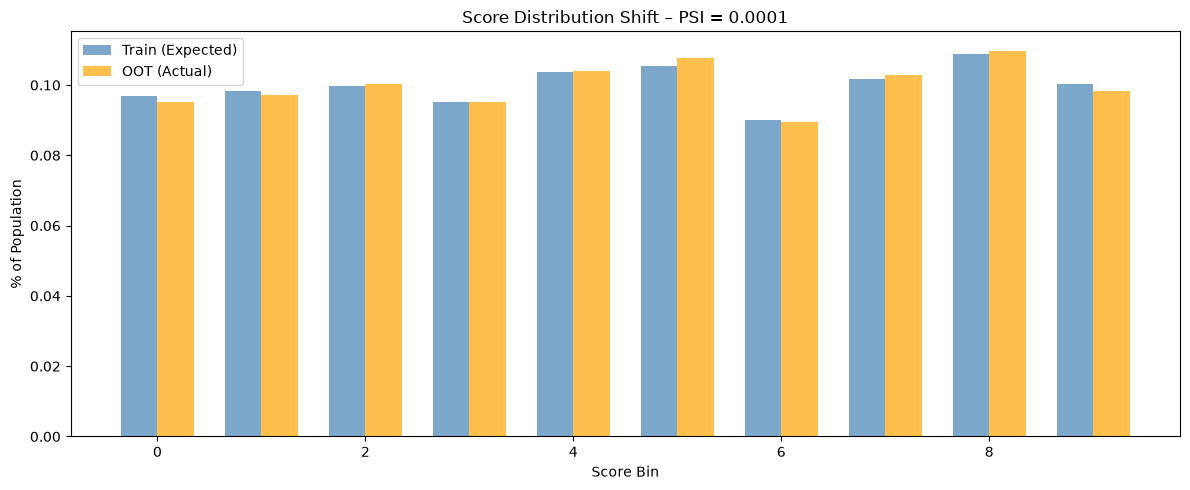

In [5]:
psi_score_lr = psi(train_scores['score'].values, oot_scores['score'].values)
psi_prob_lr = psi(p_lr_tr, p_lr_ot)


print(f"PSI (Scorecard scores) : {psi_score_lr}")
print(f"PSI (LR probabilities) : {psi_prob_lr}")


for name, val in [('Scorecard PSI', psi_score_lr), ('LR Prob PSI', psi_prob_lr)]:
    if val < 0.1:
        status = '✅ Stable – no action needed（稳定，无需处理）'
    elif val < 0.2:
        status = '⚠️ Moderate shift – monitor closely（轻度漂移，持续监控）'
    else:
        status = '❌ Significant shift – model review required（严重漂移，需要复盘模型）'
    print(f"{name}: {val} → {status}")

bins = 10
breakpoints = np.percentile(train_scores['score'], np.linspace(0, 100, bins + 1))
breakpoints = np.unique(breakpoints)  

exp_pct = np.histogram(train_scores['score'], bins=breakpoints)[0] / len(train_scores)
act_pct = np.histogram(oot_scores['score'], bins=breakpoints)[0] / len(oot_scores)

x = np.arange(len(exp_pct)) 
width = 0.35                

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, exp_pct, width, label='Train (Expected)', color='steelblue', alpha=0.7)
ax.bar(x + width/2, act_pct, width, label='OOT (Actual)',    color='orange', alpha=0.7)

ax.set_title(f'Score Distribution Shift – PSI = {psi_score_lr}')
ax.set_xlabel('Score Bin')
ax.set_ylabel('% of Population')
ax.legend()

plt.tight_layout()
plt.show()



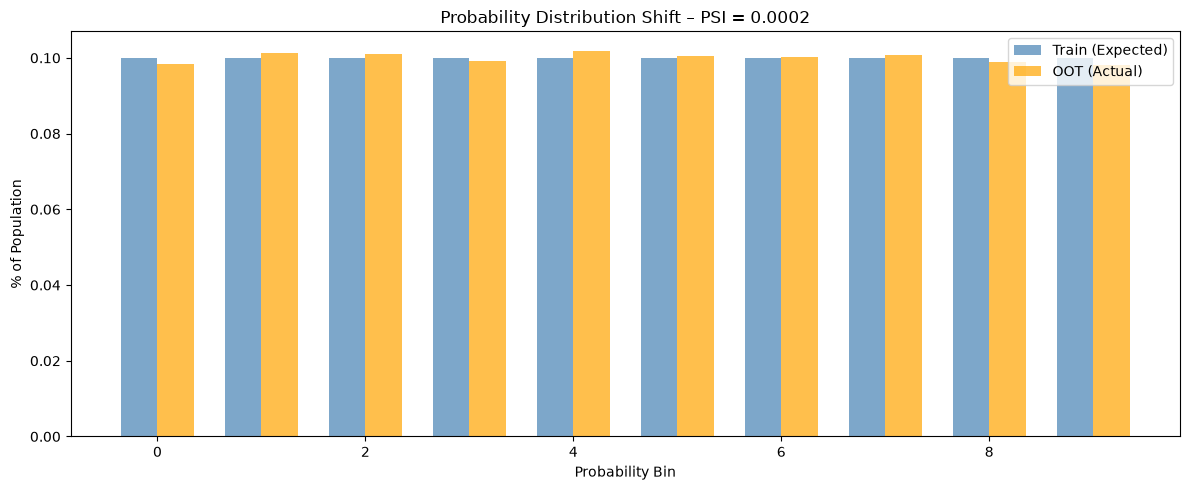

In [6]:
bins = 10
breakpoints = np.percentile(p_lr_tr, np.linspace(0, 100, bins + 1))
breakpoints = np.unique(breakpoints)

exp_pct_prob = np.histogram(p_lr_tr, bins=breakpoints)[0] / len(p_lr_tr)
act_pct_prob = np.histogram(p_lr_ot, bins=breakpoints)[0] / len(p_lr_ot)

x = np.arange(len(exp_pct_prob))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, exp_pct_prob, width, label='Train (Expected)', color='steelblue', alpha=0.7)
ax.bar(x + width/2, act_pct_prob, width, label='OOT (Actual)', color='orange', alpha=0.7)
ax.set_title(f'Probability Distribution Shift – PSI = {psi_prob_lr}')
ax.set_xlabel('Probability Bin')
ax.set_ylabel('% of Population')
ax.legend()
plt.tight_layout()
plt.show()

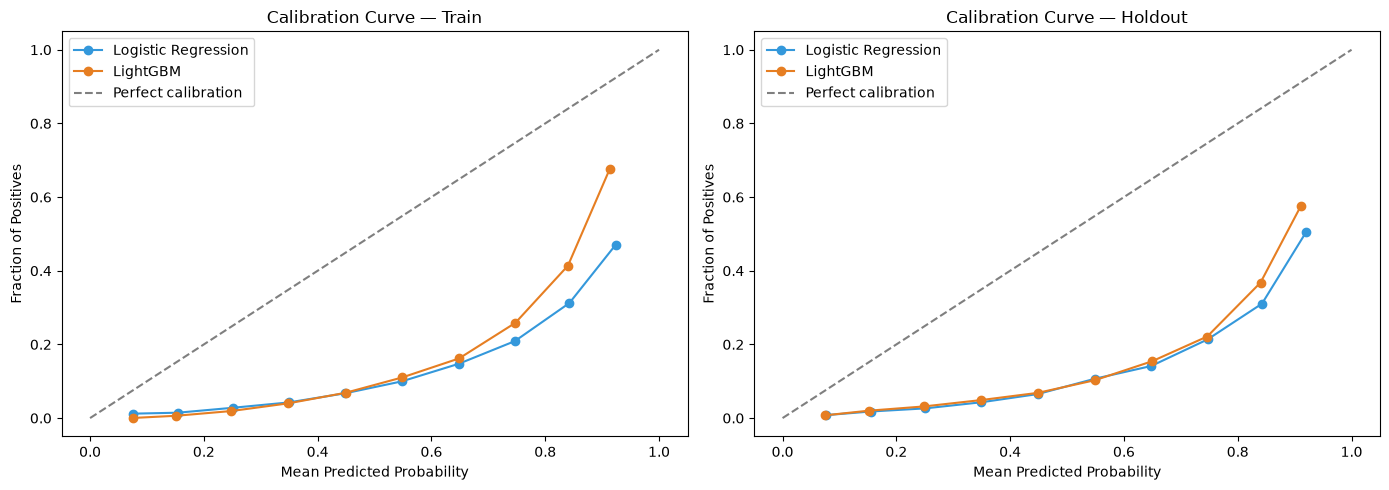

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y, p_lr, p_lgbm, label) in zip(axes, [
    (y_train, p_lr_tr, p_lgbm_tr, 'Train'),
    (y_oot,   p_lr_ot, p_lgbm_ot, 'Holdout'),
]):
    for probs, name, color in [
        (p_lr,    'Logistic Regression', '#3498db'),
        (p_lgbm,  'LightGBM',            '#e67e22'),
    ]:
        # 将预测概率分成10段，计算：分段内真实坏账占比、分段平均预测概率
        frac_pos, mean_pred = calibration_curve(y, probs, n_bins=10)
        ax.plot(mean_pred, frac_pos, marker='o', label=name, color=color)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_title(f'Calibration Curve — {label}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend()

plt.tight_layout()
plt.show()



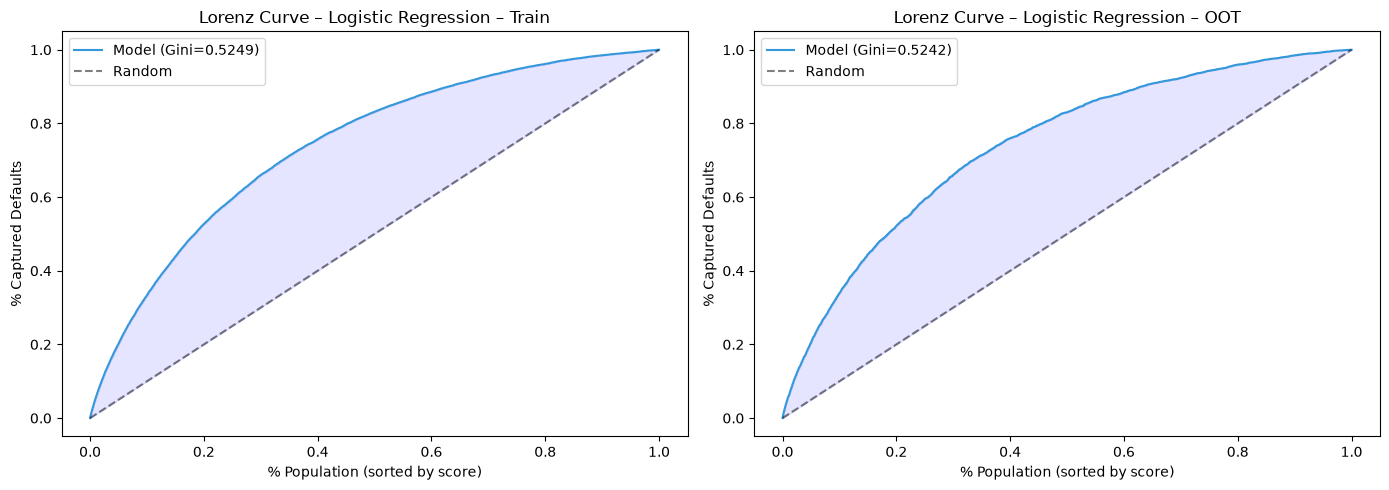

In [8]:
def lorenz_gini(y_true, y_prob, label, ax):
    """
    绘制洛伦兹曲线，搭配基尼系数可视化
    逻辑：样本按预测违约概率从高到低排序
    X：累计客户占比  Y：累计抓到的逾期坏人占全部坏人比例
    """
    # 预测概率与真实逾期标签
    df = pd.DataFrame({'prob': y_prob, 'target': y_true})
    # 按违约概率【从大到小】排序：风险最高客户排在最前面
    df = df.sort_values('prob', ascending=False).reset_index(drop=True)

    # 累计捕获坏人比例：截止当前位置，累计逾期客户 / 全部逾期客户
    cum_bad = df['target'].cumsum() / df['target'].sum()
    # 累计客户占总体样本比例
    cum_pop = (df.index + 1) / len(df)

    gini_val = gini(y_true, y_prob)

    ax.plot(cum_pop, cum_bad, label=f'Model (Gini={gini_val})', color='#3498db')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    ax.fill_between(cum_pop, cum_bad, cum_pop, alpha=0.1, color='blue')


    ax.set_title(f'Lorenz Curve – {label}')
    ax.set_xlabel('% Population (sorted by score)') # X：累计客户占比（按风险排序）
    ax.set_ylabel('% Captured Defaults')            # Y：累计抓到的逾期客户占比
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lorenz_gini(y_train, p_lr_tr, 'Logistic Regression – Train', axes[0])
lorenz_gini(y_oot, p_lr_ot, 'Logistic Regression – OOT', axes[1])

plt.tight_layout()
plt.show()



## Validation Summary

### Final Model Comparison
| Model | AUC Train | AUC Holdout | KS Train | KS Holdout | Gini Holdout |
|---|---|---|---|---|---|
| DummyClassifier | ~0.50 | ~0.50 | ~0.00 | ~0.00 | ~0.00 |
| Logistic Regression | 0.7625 | 0.7621 | 0.3941 | 0.3989 | 0.5242 |
| LightGBM | 0.8278 | 0.7723 | 0.4987 | 0.4149 | 0.5446 |

### Population Stability Index
| Metric | PSI | Status |
|---|---|---|
| Scorecard Scores | 0.0002 | Good |
| LR Probabilities | 0.0002 | Good |


### Conclusions
- Model is **stable** across Train→OOT (PSI < 0.1) ✅
- KS = [0.39] — [acceptable/good] separation for retail credit scoring ✅
- Gini = [0.54] — [acceptable/good] discriminatory power ✅
- Logistic Regression selected for Scorecard due to interpretability 
  and regulatory compliance

**Next step:** Final summary → notebook 09